api: Y4CDrqJpnPkt6MPeK2c5Jf5WjMczQ7wo5Aa91v8R

the scrape for  total carbon emission in 3 states


In [3]:
import requests
import pandas as pd

API_KEY = "Y4CDrqJpnPkt6MPeK2c5Jf5WjMczQ7wo5Aa91v8R"

url = "https://api.eia.gov/v2/seds/data/"
params = {
    "api_key": API_KEY,
    "frequency": "annual",
    "data[0]": "value",
    "facets[stateId][]": "US",      
    "facets[seriesId][]": "TETCE",  
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000
}
response = requests.get(url, params=params)
data = response.json()["response"]["data"]
df = pd.DataFrame(data)
df = df[["stateId", "period", "value"]]
df.columns = ["State", "Year", "Total_CO2_Emissions"]
df["Year"] = pd.to_numeric(df["Year"])
df["Total_CO2_Emissions"] = pd.to_numeric(df["Total_CO2_Emissions"])
df = df[(df["Year"] >= 2001) & (df["Year"] <= 2010)]
df["Period"] = df["Year"].apply(
    lambda x: "Pre-policy" if x <= 2005 else "Post-policy"
)
df.to_csv("US_carbon_emission_2001_2010.csv", index=False)
print(df)

   State  Year  Total_CO2_Emissions       Period
41    US  2001             5763.090   Pre-policy
42    US  2002             5801.606   Pre-policy
43    US  2003             5874.545   Pre-policy
44    US  2004             5981.280   Pre-policy
45    US  2005             5994.695   Pre-policy
46    US  2006             5916.172  Post-policy
47    US  2007             6001.215  Post-policy
48    US  2008             5808.692  Post-policy
49    US  2009             5388.840  Post-policy
50    US  2010             5581.224  Post-policy


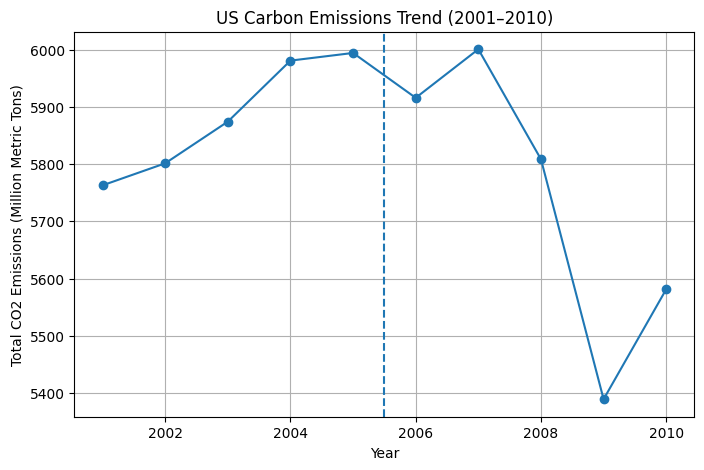

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Year"], df["Total_CO2_Emissions"], marker="o")
plt.axvline(x=2005.5, linestyle="--")
plt.title("US Carbon Emissions Trend (2001–2010)")
plt.xlabel("Year")
plt.ylabel("Total CO2 Emissions (Million Metric Tons)")

plt.grid(True)

plt.show()

the scrape for total carbon emission in 3 states

In [7]:
import requests
import pandas as pd

API_KEY = "Y4CDrqJpnPkt6MPeK2c5Jf5WjMczQ7wo5Aa91v8R"   
BASE_URL = "https://api.eia.gov/v2/seds/data/"

#STATES WE Want
STATE_CODES = ["CA","TX","NY"]
    

def fetch_total_co2(api_key: str, start_year: int = 1995, end_year: int = 2010) -> pd.DataFrame:

    params = [
        ("api_key", api_key),
        ("frequency", "annual"),
        ("data[0]", "value"),
        ("facets[seriesId][]", "TETCE"),   # total CO2 emissions for all sectors
        ("sort[0][column]", "stateId"),
        ("sort[0][direction]", "asc"),
        ("sort[1][column]", "period"),
        ("sort[1][direction]", "asc"),
        ("length", "5000")
    ]

    for state in STATE_CODES:
        params.append(("facets[stateId][]", state))

    response = requests.get(BASE_URL, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()

    rows = payload["response"]["data"]
    df = pd.DataFrame(rows)

    # get the needed 
    df = df[["stateId", "period", "value"]].copy()
    df.columns = ["State", "Year", "Total carbon emissions"]

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Total carbon emissions"] = pd.to_numeric(df["Total carbon emissions"], errors="coerce")

    # year
    df = df[(df["Year"] >= start_year) & (df["Year"] <= end_year)]

    #rank
    df = df.sort_values(["State", "Year"]).reset_index(drop=True)

    return df


if __name__ == "__main__":
    df_co2 = fetch_total_co2(API_KEY, 2001, 2010)

    print(df_co2.head(20))
    print(f"\nTotal rows: {len(df_co2)}")


    df_co2.to_csv("state_total_co2_2001_2010.csv", index=False)
    print("\nSaved to state_total_co2_2001_2010.csv")

   State  Year  Total carbon emissions
0     CA  2001                 385.846
1     CA  2002                 384.151
2     CA  2003                 374.860
3     CA  2004                 392.673
4     CA  2005                 389.479
5     CA  2006                 397.967
6     CA  2007                 402.611
7     CA  2008                 384.159
8     CA  2009                 370.625
9     CA  2010                 357.038
10    NY  2001                 207.820
11    NY  2002                 201.995
12    NY  2003                 212.921
13    NY  2004                 215.142
14    NY  2005                 211.225
15    NY  2006                 193.629
16    NY  2007                 199.772
17    NY  2008                 189.970
18    NY  2009                 173.874
19    NY  2010                 184.970

Total rows: 30

Saved to state_total_co2_2001_2010.csv


In [5]:
pip install pandas xlrd requests


Note: you may need to restart the kernel to use updated packages.


the scrape for solar and wind scrape for 3 states

In [10]:
import pandas as pd

url = "https://www.eia.gov/electricity/data/state/annual_generation_state.xls
df = pd.read_excel(url, sheet_name="Net_Generation_1990-2024 Final", header=1)
df = df[df["TYPE OF PRODUCER"] == "Total Electric Power Industry"].copy()
#2001-2010
df = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2010)].copy()
df = df[df["ENERGY SOURCE"].isin(["Wind", "Solar Thermal and Photovoltaic"])].copy()

# MWh -> GWh
df["Generation_GWh"] = df["GENERATION (Megawatthours)"] / 1000
renewable_df = (
    df.pivot_table(
        index=["STATE", "YEAR"],
        columns="ENERGY SOURCE",
        values="Generation_GWh",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

renewable_df = renewable_df.rename(columns={
    "STATE": "State",
    "YEAR": "Year",
    "Wind": "Wind generation (GWh)",
    "Solar Thermal and Photovoltaic": "Solar generation (GWh)"
})

renewable_df = renewable_df.sort_values(["State", "Year"]).reset_index(drop=True)
renewable_df.to_csv("state_wind_solar_2001_2010.csv", index=False)

print(renewable_df.head(20))
print("\nSaved to state_wind_solar_2001_2010.csv")

ENERGY SOURCE State  Year  Solar generation (GWh)  Wind generation (GWh)
0                AK  2001                   0.000                  0.950
1                AK  2005                   0.000                  0.589
2                AK  2006                   0.000                  0.788
3                AK  2007                   0.000                  1.012
4                AK  2008                   0.000                  0.068
5                AK  2009                   0.000                  7.027
6                AK  2010                   0.000                 12.607
7                AZ  2001                   0.489                  0.000
8                AZ  2002                   0.459                  0.000
9                AZ  2003                   0.395                  0.000
10               AZ  2004                   4.265                  0.000
11               AZ  2005                  13.581                  0.000
12               AZ  2006                  13.134  

the scrape for all fuels for 3 states

In [14]:
import pandas as pd


url = "https://www.eia.gov/electricity/data/state/annual_generation_state.xls"
df = pd.read_excel(url, sheet_name=0, header=1)
target_states = ["CA", "TX", "NY"]
df = df[df["STATE"].isin(target_states)].copy()
df = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2010)].copy()
df = df[df["TYPE OF PRODUCER"] == "Total Electric Power Industry"].copy()
df = df[["STATE", "YEAR", "ENERGY SOURCE", "GENERATION (Megawatthours)"]].copy()
df["Generation (GWh)"] = df["GENERATION (Megawatthours)"] / 1000
df.loc[df["Generation (GWh)"].abs() < 0.01, "Generation (GWh)"] = 0
long_df = df.rename(columns={
    "STATE": "State",
    "YEAR": "Year",
    "ENERGY SOURCE": "Fuel"
})[["State", "Year", "Fuel", "Generation (GWh)"]]

long_df = long_df.sort_values(["State", "Year", "Fuel"]).reset_index(drop=True)
long_df.to_csv("CA_TX_NY_all_fuels_2001_2010_long.csv", index=False)
wide_df = (
    long_df.pivot_table(
        index=["State", "Year"],
        columns="Fuel",
        values="Generation (GWh)",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)
wide_df.to_csv("CA_TX_NY_all_fuels_2001_2010_wide.csv", index=False)

print("\nLong format preview:")
print(long_df.head(20))

print("\nWide format preview:")
print(wide_df.head(10))

print("\nSaved:")
#print("CA_TX_NY_all_fuels_2001_2010_long.csv")
#print("CA_TX_NY_all_fuels_2001_2010_wide.csv")

['YEAR', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Megawatthours)']
   YEAR STATE               TYPE OF PRODUCER               ENERGY SOURCE  \
0  1990    AK  Total Electric Power Industry                       Total   
1  1990    AK  Total Electric Power Industry                        Coal   
2  1990    AK  Total Electric Power Industry  Hydroelectric Conventional   
3  1990    AK  Total Electric Power Industry                 Natural Gas   
4  1990    AK  Total Electric Power Industry                   Petroleum   

   GENERATION (Megawatthours)  
0                   5599506.0  
1                    510573.0  
2                    974521.0  
3                   3466261.0  
4                    497116.0  

Long format preview:
   State  Year                            Fuel  Generation (GWh)
0     CA  2001                            Coal          2232.851
1     CA  2001                      Geothermal         12181.294
2     CA  2001      Hydroelectric Conventional   

data cleaning

In [17]:

import pandas as pd
df = pd.read_csv("CA_TX_NY_all_fuels_2001_2010_wide.csv")
df = df.drop(columns=["Pumped Storage"])
df = df.rename(columns={"Other": "Other_Renewables"})
df["carbon_related_fuel"] = df[
    [
        "Coal",
        "Natural Gas",
        "Other Biomass",
        "Other Gases",
        "Petroleum",
        "Wood and Wood Derived Fuels"
    ]
].sum(axis=1)
df = df.drop(columns = ["Coal","Natural Gas","Other Biomass","Other Gases", "Petroleum","Wood and Wood Derived Fuels"])
df.to_csv("all_fuels_clean1.csv", index=False)

monthly data for TX doing linear regression

In [ ]:
import pandas as pd

url = "https://www.eia.gov/electricity/data/state/generation_monthly.xlsx"
xls = pd.ExcelFile(url)

dfs = []

for s in xls.sheet_names:
    temp = pd.read_excel(xls, sheet_name=s, header=None)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df = df.iloc[:, :6].copy()
df.columns = [
    "YEAR",
    "MONTH",
    "STATE",
    "TYPE_OF_PRODUCER",
    "ENERGY_SOURCE",
    "GENERATION"
]


df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["MONTH"] = pd.to_numeric(df["MONTH"], errors="coerce")
df["GENERATION"] = pd.to_numeric(df["GENERATION"], errors="coerce")

df = df[df["STATE"] == "TX"].copy()
df = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2010)].copy()
df = df[df["TYPE_OF_PRODUCER"] == "Total Electric Power Industry"].copy()


df["Generation_GWh"] = df["GENERATION"] / 1000


wide_df = (
    df.pivot_table(
        index=["STATE", "YEAR", "MONTH"],
        columns="ENERGY_SOURCE",
        values="Generation_GWh",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

print(sorted(wide_df["YEAR"].unique()))
print(wide_df.groupby("YEAR")["MONTH"].nunique())
print(wide_df.shape)

wide_df.to_csv("TX_all_fuels_2001_2010_monthly3.csv", index=False)


data cleaning for TX monthly data

In [2]:
import pandas as pd
df = pd.read_csv("TX_all_fuels_2001_2010_monthly3.csv")
df = df.rename(columns={"Other": "Other_Renewables"})
df["carbon_related_fuel"] = df[
    [
        "Coal",
        "Natural Gas",
        "Other Biomass",
        "Other Gases",
        "Petroleum",
        "Wood and Wood Derived Fuels"
    ]
].sum(axis=1)
df = df.drop(columns = ["Coal","Natural Gas","Other Biomass","Other Gases", "Petroleum","Wood and Wood Derived Fuels"])
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].clip(lower=0)
df.to_csv("TX_fuels_clean1.csv", index=False)